In [1]:
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler

In [2]:
paradigm = P300(resample=32, tmin=0, tmax=1)
dataset = BNCI2014008()

In [3]:
subject, session, run = 2, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=10, n_times=347704
    Range : 0 ... 347703 =      0.000 ...  1358.215 secs
Ready.
Not setting metadata
4200 matching events found
No baseline correction applied
0 bad epochs dropped


Number of events,4200
Events,NonTarget: 3500Target: 700
Time range,0.000 – 0.969 sec
Baseline,off


In [4]:
scaler= Scaler(scalings='mean', with_mean=False)
epochs._data = scaler.fit_transform(epochs._data)

In [5]:
X = epochs.get_data()
y = labels
print(X.shape)

(4200, 8, 32)


In [6]:
hoda = HODA(max_iter=256, rank=(3,3), tol=1e-12, initialize ='random', verbose=True, toeplitz=1, taper=1)
hoda.fit(X,y)

Iteration 0  updates: [3.5343604  5.94878502]
Iteration 1  updates: [1.70360466 1.44356276]
Iteration 2  updates: [1.87191336 2.38036833]
Iteration 3  updates: [1.87117404 1.2909167 ]
Iteration 4  updates: [1.51371868 1.19940391]
Iteration 5  updates: [1.83644734 1.14737794]
Iteration 6  updates: [2.47374749 1.02259485]
Iteration 7  updates: [2.76331021 2.68201681]
Iteration 8  updates: [2.76391778 0.72653148]
Iteration 9  updates: [2.81115969 0.56928353]
Iteration 10  updates: [2.8101511  0.48518689]
Iteration 11  updates: [1.99962604 0.38705513]
Iteration 12  updates: [1.99967256 0.34119477]
Iteration 13  updates: [0.07176499 0.31759463]
Iteration 14  updates: [0.0740263  0.25387058]
Iteration 15  updates: [0.03371632 0.25861469]
Iteration 16  updates: [0.03509717 0.17892647]
Iteration 17  updates: [0.01630276 0.18794049]
Iteration 18  updates: [0.0171073  0.11389075]
Iteration 19  updates: [0.00805382 0.1207402 ]
Iteration 20  updates: [0.00850521 0.0664003 ]
Iteration 21  updates: 

HODA(initialize='random', max_iter=256, rank=(3, 3), tol=1e-12, verbose=True)

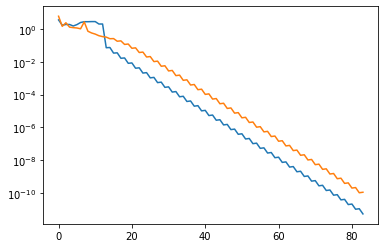

In [7]:
plt.semilogy(hoda.updates_[:,:hoda.iter_].T)
plt.show()

(3, 3)


/tmp/ipykernel_53113/2637232329.py:16: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


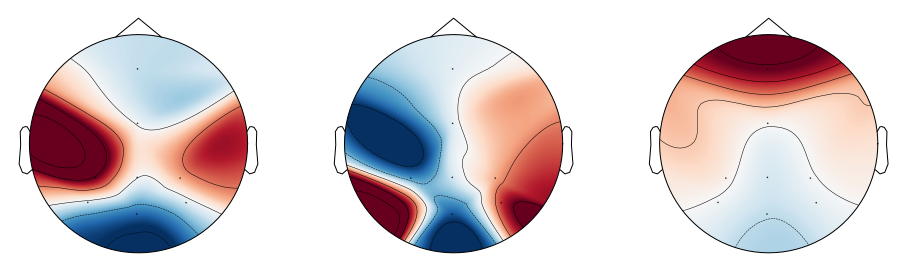

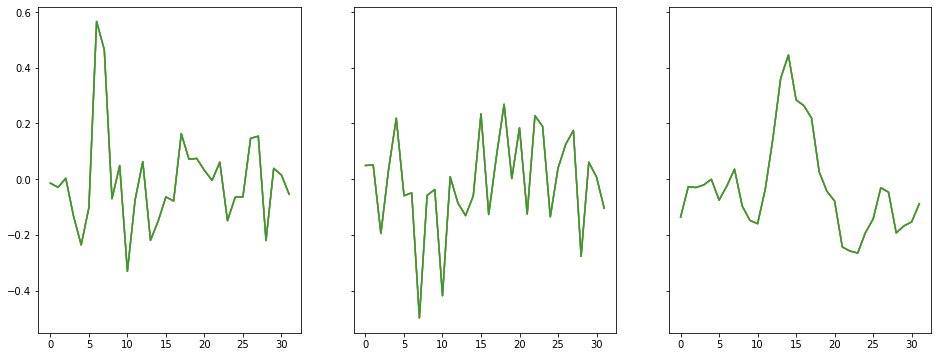

In [8]:
print(hoda.rank_)
for k in range(2):
    Uk = hoda.projs_[k]
    vmax = np.max(np.abs(Uk))
    fig, axs = plt.subplots(1,Uk.shape[1], figsize=(16,6), sharex=True, sharey=True)
    if Uk.shape[1]==1:
        axs = [axs]
    for i in range(Uk.shape[1]):
        if k==0:
            plot_topomap(Uk[:,i], epochs.info, axes=axs[i], show=False)        
        elif k == 1:
            for i in range(Uk.shape[1]):
                axs[i].plot(Uk[:,i])
        else:
            sns.heatmap(Uk, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()

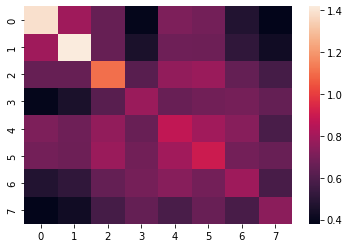

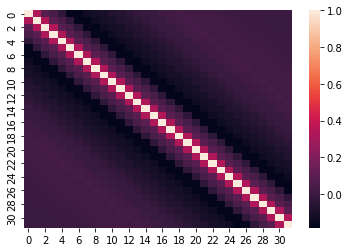

In [9]:
for k in range(2):
    sns.heatmap(hoda.scatter_w_[k])
    plt.show()

/tmp/ipykernel_53113/244461026.py:15: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


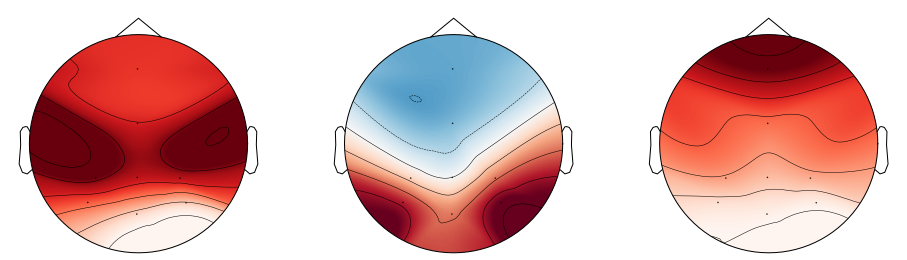

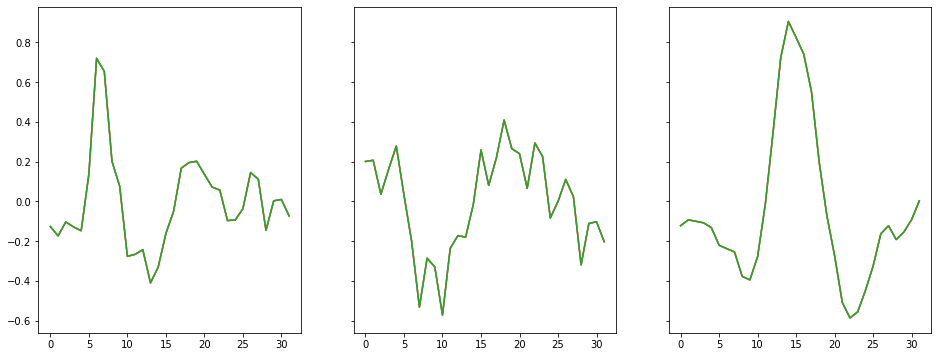

In [10]:
for k in range(2):
    patterns = (hoda.projs_[k].T@hoda.scatter_w_[k]).T
    vmax = np.max(np.abs(Uk))
    fig, axs = plt.subplots(1,patterns.shape[1], figsize=(16,6), sharex=True, sharey=True)
    if Uk.shape[1]==1:
        axs = [axs]
    for i in range(patterns.shape[1]):
        if k==0:
            plot_topomap(patterns[:,i], epochs.info, axes=axs[i], show=False)        
        elif k == 1:
            for i in range(patterns.shape[1]):
                axs[i].plot(patterns[:,i])
        else:
            sns.heatmap(patterns, cmap='RdBu_r', vmin=-vmax, vmax=vmax, ax=axs[i])
    fig.show()

In [11]:
Xt = hoda.transform(X)

/home/arne/.virtualenvs/hoda_venv/lib64/python3.10/site-packages/sklearn/manifold/_t_sne.py:795: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/home/arne/.virtualenvs/hoda_venv/lib64/python3.10/site-packages/sklearn/manifold/_t_sne.py:805: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


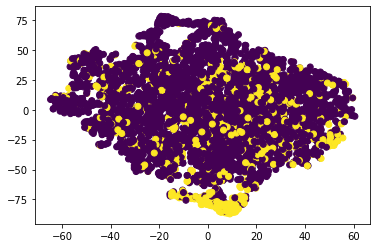

In [12]:
tsne = TSNE(n_components=2)
X_pc = tsne.fit_transform(Xt)
plt.scatter(X_pc[:,0], X_pc[:,1],c=labels=='Target')

In [13]:
lda = LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')
lda.fit(Xt,y)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [14]:
roc_auc_score(y, lda.predict_proba(Xt)[:,1])

0.8063253061224489